In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score


In [3]:
df=sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [13]:
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

In [11]:
df['age']=df['age'].fillna(df['age'].mean)
df['embarked']=df['embarked'].fillna(df['embarked'].mod)
df['embark_town']=df['embark_town'].fillna(df['embark_town'].mod)

In [12]:
df.drop(columns='deck',inplace=True)

In [15]:
df.shape

(891, 14)

In [16]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  embark_town  891 non-null    object  
 12  alive        891 non-null    object  
 13  alone        891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), object(5)
memory usage: 79.4+ KB


In [26]:
x=df.drop(columns=['alive','alone','survived','embarked','embark_town'])
y=df['survived']

In [42]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   pclass      891 non-null    int64  
 1   sex         891 non-null    int64  
 2   age         891 non-null    float64
 3   sibsp       891 non-null    int64  
 4   parch       891 non-null    int64  
 5   fare        891 non-null    float64
 6   class       891 non-null    int64  
 7   who         891 non-null    object 
 8   adult_male  891 non-null    int64  
dtypes: float64(2), int64(6), object(1)
memory usage: 62.8+ KB


In [43]:
la=LabelEncoder()
x['sex']=la.fit_transform(x['sex'])
x['class']=la.fit_transform(x['class'])
x['adult_male']=la.fit_transform(x['adult_male'])
x['who']=la.fit_transform(x['who'])

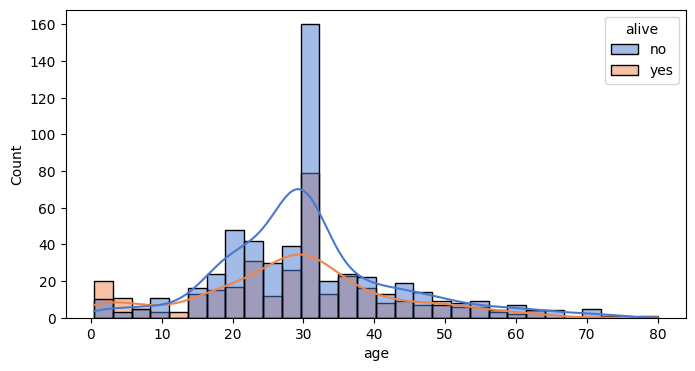

In [77]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='age', hue='alive', kde=True, multiple='layer', palette='muted', bins=30)
plt.show()

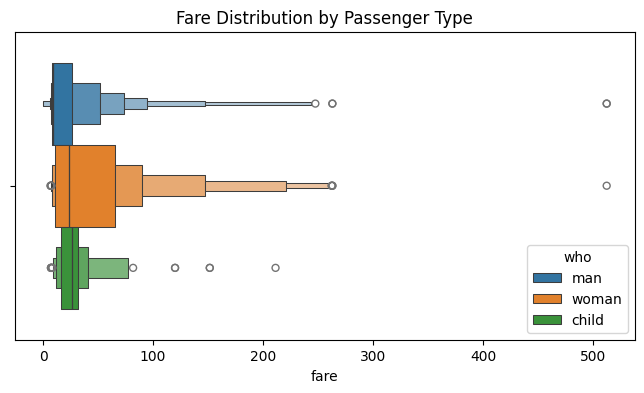

In [86]:
plt.figure(figsize=(8, 4))
sns.boxenplot(data=df,x='fare',hue='who')
plt.title('Fare Distribution by Passenger Type')
plt.show()

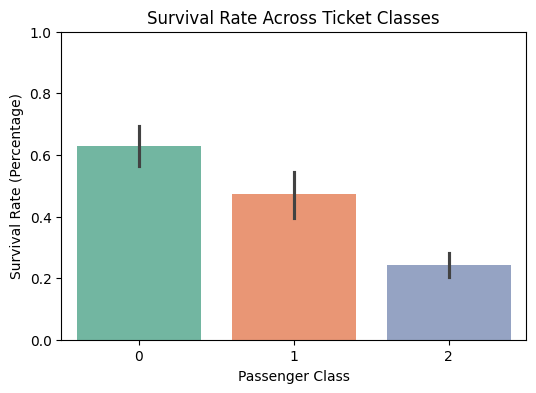

In [81]:
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='class', y='survived', hue='class', palette='Set2', legend=False)

plt.title('Survival Rate Across Ticket Classes')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate (Percentage)')
plt.ylim(0, 1)
plt.show()

In [44]:
x_train,x_test,y_train,y_test =train_test_split(x,y,random_state=42,test_size=0.2)

In [45]:
base_pipe=Pipeline([
    ('StandardScaler',StandardScaler()),
    ('Logistic_Regression',LogisticRegression())
])

In [46]:
base_pipe.fit(x_train, y_train)

,steps,"[('StandardScaler', ...), ('Logistic_Regression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [47]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

In [48]:
param_grid = {
    'classifier__C': [0.01, 0.1, 1.0, 10.0],
    'classifier__class_weight': [None, 'balanced'],
    'classifier__solver': ['liblinear', 'lbfgs']
}

In [50]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid_search.fit(x_train, y_train)
tuned_pipe = grid_search.best_estimator_

In [51]:
def evaluate(model, X_test, y_test):
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    return {
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall": recall_score(y_test, preds),
        "F1-Score": f1_score(y_test, preds),
        "ROC-AUC": roc_auc_score(y_test, probs)
    }

In [57]:
orig_metrics = evaluate(base_pipe, x_test, y_test)
tuned_metrics = evaluate(tuned_pipe, x_test, y_test)

In [69]:
for i in orig_metrics:
    print(f'Original {i}: {orig_metrics[i]:.4f} | Tuned {i}: {tuned_metrics[i]:.4f}')

Original Accuracy: 0.8045 | Tuned Accuracy: 0.8045
Original Precision: 0.7910 | Tuned Precision: 0.7910
Original Recall: 0.7162 | Tuned Recall: 0.7162
Original F1-Score: 0.7518 | Tuned F1-Score: 0.7518
Original ROC-AUC: 0.8835 | Tuned ROC-AUC: 0.8837


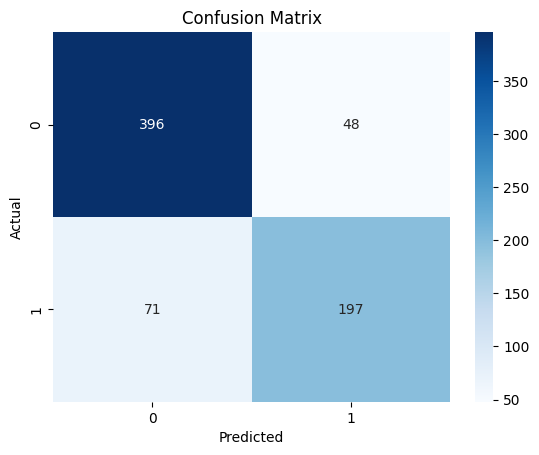

In [ ]:
y_train_pred = base_pipe.predict(x_train)
cm = confusion_matrix(y_train, y_train_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
y_train_pred_tuned = tuned_pipe.predict(x_train)
cm_tuned = confusion_matrix(y_train, y_train_pred_tuned)
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix (Tuned)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()